# EDA02 — Market Price Analysis
### Intraday Power Market Analysis | AT & DE | EPEX SPOT

This notebook analyses the statistical properties and patterns of intraday 
trade prices in the Austrian (AT) and German (DE) markets.

The cleaned data produced in EDA01 is loaded directly from Parquet — no 
re-cleaning is needed here.

1. Basic price statistics — mean, median, std, min, max
2. Price distribution — histogram, are there outliers?
3. Negative prices — how frequent, when do they happen?
4. Volume over time — how much is traded per day?
5. Delivery area breakdown — which zones are most active?

**Data coverage:**
- AT: December 31 2023 → July 5 2024
- DE: December 31 2023 → April 8 2024
- Overlapping period used for direct comparisons: January 2024 → April 8 2024

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_at = pd.read_parquet("../data/AT/processed/intraday_trades_AT.parquet")
df_de = pd.read_parquet("../data/DE/processed/intraday_trades_DE.parquet")

print("=== AT ===")
print(f"Shape: {df_at.shape}")
print(f"Date range: {df_at['time'].min().date()} → {df_at['time'].max().date()}")

print("\n=== DE ===")
print(f"Shape: {df_de.shape}")
print(f"Date range: {df_de['time'].min().date()} → {df_de['time'].max().date()}")

=== AT ===
Shape: (3664611, 20)
Date range: 2023-12-31 → 2024-07-05

=== DE ===
Shape: (9056883, 20)
Date range: 2023-12-31 → 2024-04-08


In [3]:
df_at.head()

,contract_id,time,trade_id,buy_delivery_area,sell_delivery_area,price,quantity,self_trade,market,date,hour,minute,day_of_week,week,month,year,is_weekend,cross_border,is_domestic,traded_value_eur
0,13564578,2024-01-19 22:10:12.274000+01:00,1588131854,10YDE-VE-------2,10YAT-APG------L,63.80,0.3,False,AT,2024-01-19,22,10,4,3,1,2024,False,True,True,19.140
1,13564578,2024-01-19 22:11:22.180000+01:00,1588132455,10YDE-VE-------2,10YAT-APG------L,64.56,5.3,False,AT,2024-01-19,22,11,4,3,1,2024,False,True,True,342.168
2,13564578,2024-01-19 22:13:12.589000+01:00,1588133421,10YNL----------L,10YAT-APG------L,64.36,0.8,False,AT,2024-01-19,22,13,4,3,1,2024,False,True,True,51.488
3,13564578,2024-01-19 22:13:53.567000+01:00,1588133703,10YDE-VE-------2,10YAT-APG------L,64.10,0.2,False,AT,2024-01-19,22,13,4,3,1,2024,False,True,True,12.820
4,13564578,2024-01-19 22:13:53.667000+01:00,1588133705,10YDE-VE-------2,10YAT-APG------L,64.10,0.7,False,AT,2024-01-19,22,13,4,3,1,2024,False,True,True,44.870


In [4]:
df_de.head()

,contract_id,time,trade_id,buy_delivery_area,sell_delivery_area,price,quantity,self_trade,market,date,hour,minute,day_of_week,week,month,year,is_weekend,cross_border,is_domestic,traded_value_eur
0,13565042,2024-01-19 17:41:44.601000+01:00,1588006498,10YDE-EON------1,10YDE-VE-------2,74.07,0.3,False,DE,2024-01-19,17,41,4,3,1,2024,False,True,True,22.221
1,13565042,2024-01-19 17:41:44.638000+01:00,1588006499,10YDE-EON------1,10YDE-VE-------2,72.31,0.1,False,DE,2024-01-19,17,41,4,3,1,2024,False,True,True,7.231
2,13565042,2024-01-19 17:41:44.638000+01:00,1588006500,10YDE-RWENET---I,10YDE-VE-------2,72.31,0.1,False,DE,2024-01-19,17,41,4,3,1,2024,False,True,True,7.231
3,13565042,2024-01-19 18:01:10.968000+01:00,1588016160,10YDE-VE-------2,10YDE-VE-------2,71.83,0.3,False,DE,2024-01-19,18,1,4,3,1,2024,False,False,True,21.549
4,13565042,2024-01-19 18:01:10.968000+01:00,1588016161,10YDE-VE-------2,10YDE-VE-------2,71.80,0.5,False,DE,2024-01-19,18,1,4,3,1,2024,False,False,True,35.900


## 2. Basic Price Statistics

The starting point for any price analysis is understanding the basic 
statistical properties of the data. Before plotting anything or drawing 
any conclusions, the distribution needs to be summarised numerically.

`describe()` gives the standard summary statistics. The default only shows 
25%, 50%, 75% percentiles — too coarse for price data where the extremes 
matter. Custom percentiles are added:

- **1% and 99%** — where the extreme outliers start
- **5% and 95%** — the outer edges of normal trading range  
- **25%, 50%, 75%** — the core of the distribution

This gives a full picture from the most negative prices all the way up 
to the most extreme spikes, without looking at just the min and max which 
are often exchange-imposed price caps.

In [5]:
# Basic price statistics for both markets
print("=== AT Price Statistics ===")
print(df_at["price"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

print("\n=== DE Price Statistics ===")
print(df_de["price"].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

=== AT Price Statistics ===


count    3.664611e+06
mean     6.919675e+01
std      5.133874e+01
min     -1.919000e+03
1%      -8.240000e+01
5%      -8.780000e+00
25%      5.274000e+01
50%      7.520000e+01
75%      9.370000e+01
95%      1.276900e+02
99%      1.789300e+02
max      2.000010e+03
Name: price, dtype: float64

=== DE Price Statistics ===
count    9.056883e+06
mean     6.931835e+01
std      4.847776e+01
min     -5.000000e+03
1%      -5.669000e+01
5%      -2.600000e+00
25%      5.208000e+01
50%      7.241000e+01
75%      9.290000e+01
95%      1.264000e+02
99%      1.662100e+02
max      6.999990e+03
Name: price, dtype: float64


### Interpretation

**Central tendency**  
Both markets trade around the same level — AT mean 69.20 €/MWh, DE mean 69.32 €/MWh. The markets are tightly coupled as expected given the AT-DE price zone interconnection.

**Skewness**  
In both markets the median sits above the mean:
- AT: mean 69.20 vs median 75.20 €/MWh
- DE: mean 69.32 vs median 72.41 €/MWh

Mean below median signals left skew — extreme negative prices pull the average downward. The bulk of trading happens above the mean.

**Normal trading range**  
The 5th to 95th percentile captures 90% of all trades:
- AT: −8.78 to 127.69 €/MWh
- DE: −2.60 to 126.40 €/MWh

DE has a notably higher 5th percentile (−2.60 vs −8.78), meaning deep negative prices are less common in the German market within this range.

**Extreme values**  
The official EPEX SPOT price limits for intraday continuous trading are −9,999 to +9,999 €/MWh for both AT and DE — confirmed in the 2024 EPEX Trading Brochure and current Operational Rules (March 2026). This means the extremes observed in the dataset are **real traded prices**, not exchange-imposed caps:
- AT: −1,919 €/MWh minimum and +2,000.01 €/MWh maximum
- DE: −5,000 €/MWh minimum and +6,999.99 €/MWh maximum

The 1st percentile is more informative than the minimum for understanding realistic extreme negative prices:
- AT: −82.40 €/MWh at the 1st percentile
- DE: −56.69 €/MWh at the 1st percentile

> *Source: EPEX SPOT Operational Rules 12.03.2026, Annex 1; EPEX SPOT Trading Brochure 2024*

In [6]:
# Check how many trades hit the price boundaries
for name, df in [("AT", df_at), ("DE", df_de)]:
    print(f"=== {name} ===")
    print(f"price <= -500  : {(df['price'] <= -500).sum():,}")
    print(f"price >= 500   : {(df['price'] >= 500).sum():,}")
    print(f"price == min   : {(df['price'] == df['price'].min()).sum():,}")
    print(f"price == max   : {(df['price'] == df['price'].max()).sum():,}")
    print()
    

=== AT ===
price <= -500  : 1,145
price >= 500   : 806
price == min   : 2
price == max   : 3

=== DE ===
price <= -500  : 2,804
price >= 500   : 2,532
price == min   : 9
price == max   : 1



### Extreme Price Boundaries

The official EPEX SPOT price limits for intraday continuous trading are 
−9,999 to +9,999 €/MWh for both AT and DE — confirmed in both the 2024 
Trading Brochure and the current Operational Rules (March 2026).

This means the extremes observed in the dataset are **real traded prices**, 
not exchange-imposed caps:

- AT: −1,919 €/MWh minimum and +2,000 €/MWh maximum
- DE: −5,000 €/MWh minimum and +6,999 €/MWh maximum

Only 2 trades in AT and 9 in DE hit the dataset minimum exactly — meaning 
these are genuinely rare but real market events, not artefacts of a price 
wall. Similarly, only 3 trades in AT and 1 in DE reached the dataset maximum.

Trades beyond ±500 €/MWh are rare but meaningful:
- AT: 1,145 below −500 and 806 above +500 out of 3.6M trades
- DE: 2,804 below −500 and 2,532 above +500 out of 9M trades

These extreme events correspond to real grid stress situations — severe 
renewable oversupply pushing prices deeply negative, or acute scarcity 
events driving prices to exceptional highs. They are kept in the dataset 
but will be treated separately in volatility and spike analysis.

In [7]:
at_negative = df_at[df_at["price"] < 0]
de_negative = df_de[df_de["price"] < 0]

print("=== AT ===")
print(f"Total trades         : {len(df_at):,}")
print(f"Negative price trades: {len(at_negative):,}")

print("\n=== DE ===")
print(f"Total trades         : {len(df_de):,}")
print(f"Negative price trades: {len(de_negative):,}")

=== AT ===
Total trades         : 3,664,611
Negative price trades: 257,621

=== DE ===
Total trades         : 9,056,883
Negative price trades: 532,676


### 3. Negative Price Analysis

Negative prices are one of the most structurally important features of modern intraday power markets. They occur when renewable generation exceeds demand and generators accept negative prices rather than shutting down — effectively paying consumers to take their power.

Austria shows a higher negative price rate than Germany despite being a smaller market. This likely reflects Austria's large run-of-river hydro capacity, which generates continuously regardless of market price, contributing to oversupply during low-demand periods.

The next step is understanding *when* these negative prices occur — which hours of the day are most affected. Note: the `hour` column reflects the trade execution time, not the delivery hour. This is a proxy — a trader reacting to oversupply at 10am likely trades for delivery in the same or nearby window.

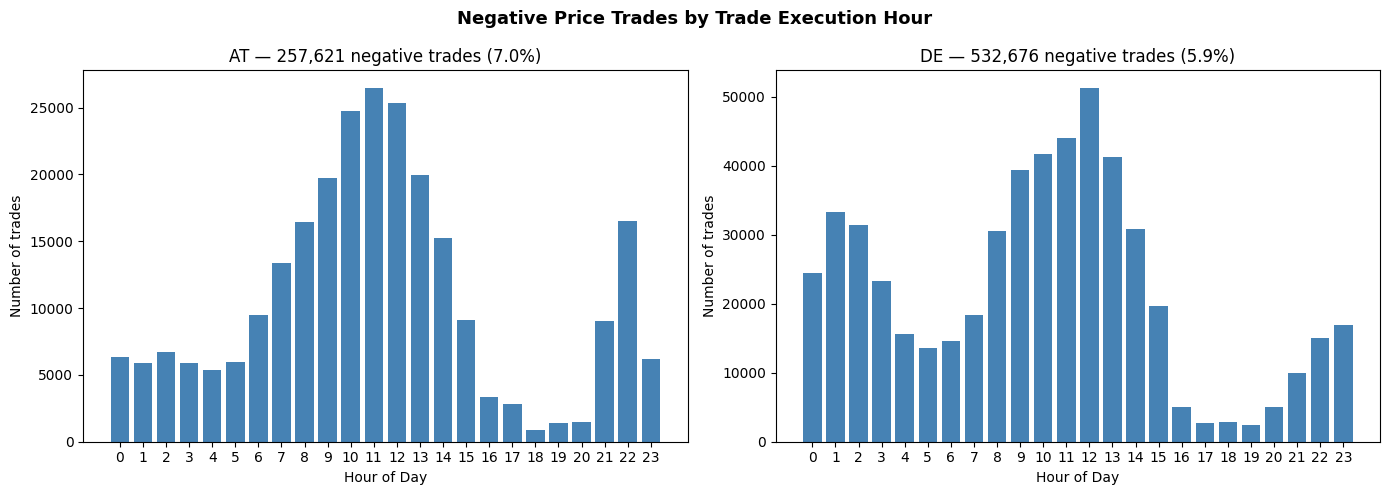

Saved → ../reports/negative_by_hour.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Negative Price Trades by Trade Execution Hour", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("AT", df_at), ("DE", df_de)]):
    neg_by_hour = df[df["price"] < 0].groupby("hour").size()
    ax.bar(neg_by_hour.index, neg_by_hour.values, color="steelblue", edgecolor="none")
    total_neg = len(df[df["price"] < 0])
    pct = total_neg / len(df) * 100
    ax.set_title(f"{name} — {total_neg:,} negative trades ({pct:.1f}%)")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Number of trades")
    ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig("../reports/negative_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/negative_by_hour.png")

## 3b. Delivery Hour Analysis — When the Power Flows

Cell 11 shows negative prices by **trade execution hour** (when the deal was struck).
This section shows the same patterns by **delivery hour** (when the electricity actually flows),
alongside the product mix and lead-time distribution extracted from the filenames in EDA01.

> **Requires EDA01 to be re-run** so the parquet files contain `delivery_start`,
> `delivery_duration_min`, and `lead_time_min`.

In [ ]:
# Guard — fail fast if parquets are stale (EDA01 not yet re-run)
required = ["delivery_start", "delivery_duration_min", "lead_time_min"]
missing  = [c for c in required if c not in df_at.columns]
if missing:
    raise RuntimeError(
        f"Missing columns: {missing}\n"
        "Re-run EDA01 to regenerate the parquet files with delivery metadata."
    )

DURATION_LABELS = {15: "15 min", 30: "30 min", 60: "1 h",
                   120: "2 h", 180: "3 h", 240: "4 h",
                   300: "5 h", 360: "6 h", 720: "12 h", 1440: "24 h"}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Delivery Hour Analysis — AT and DE", fontsize=13, fontweight="bold")

for row, (name, df) in enumerate([("AT", df_at), ("DE", df_de)]):

    # ── Product mix ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    prod = df["delivery_duration_min"].value_counts().sort_index()
    labels = [DURATION_LABELS.get(d, f"{d} min") for d in prod.index]
    bars = ax.bar(labels, prod.values, color="steelblue", edgecolor="none")
    for bar, cnt in zip(bars, prod.values):
        pct = cnt / len(df) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(df) * 0.002,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{name} — Product Mix (by delivery duration)")
    ax.set_xlabel("Product duration")
    ax.set_ylabel("Number of trades")
    ax.tick_params(axis="x", rotation=30)

    # ── Negative price rate by delivery hour ───────────────────────────────
    ax = axes[row, 1]
    del_hour = df["delivery_start"].dt.hour
    neg_rate = (
        df[df["price"] < 0].assign(dh=del_hour).groupby("dh").size()
        / df.assign(dh=del_hour).groupby("dh").size()
        * 100
    ).reindex(range(24), fill_value=0)
    ax.bar(neg_rate.index, neg_rate.values, color="tomato", edgecolor="none")
    ax.set_title(f"{name} — Negative Price Rate by Delivery Hour")
    ax.set_xlabel("Delivery hour")
    ax.set_ylabel("% trades with negative price")
    ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig("../reports/delivery_hour_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/delivery_hour_analysis.png")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lead Time Distribution — Minutes Before Delivery", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("AT", df_at), ("DE", df_de)]):
    clipped = df["lead_time_min"].clip(0, 1500)   # focus on 0–25 h window
    ax.hist(clipped, bins=100, color="steelblue", edgecolor="none", alpha=0.85)
    med = df["lead_time_min"].median()
    ax.axvline(med, color="red", linestyle="--", label=f"Median: {med:.0f} min")
    ax.set_title(f"{name} — Lead Time (capped at 1500 min)")
    ax.set_xlabel("Minutes before delivery start")
    ax.set_ylabel("Number of trades")
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/lead_time_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/lead_time_distribution.png")

## 4. Price Distribution

The histogram shows the full shape of the price distribution. The extreme tails (below −100 and above 300 €/MWh) are clipped for readability — they represent a tiny fraction of trades but would compress the main distribution into a thin line.

A log-scale y-axis is used because the distribution is highly concentrated around 50–100 €/MWh, with rapidly decreasing frequency towards the extremes.

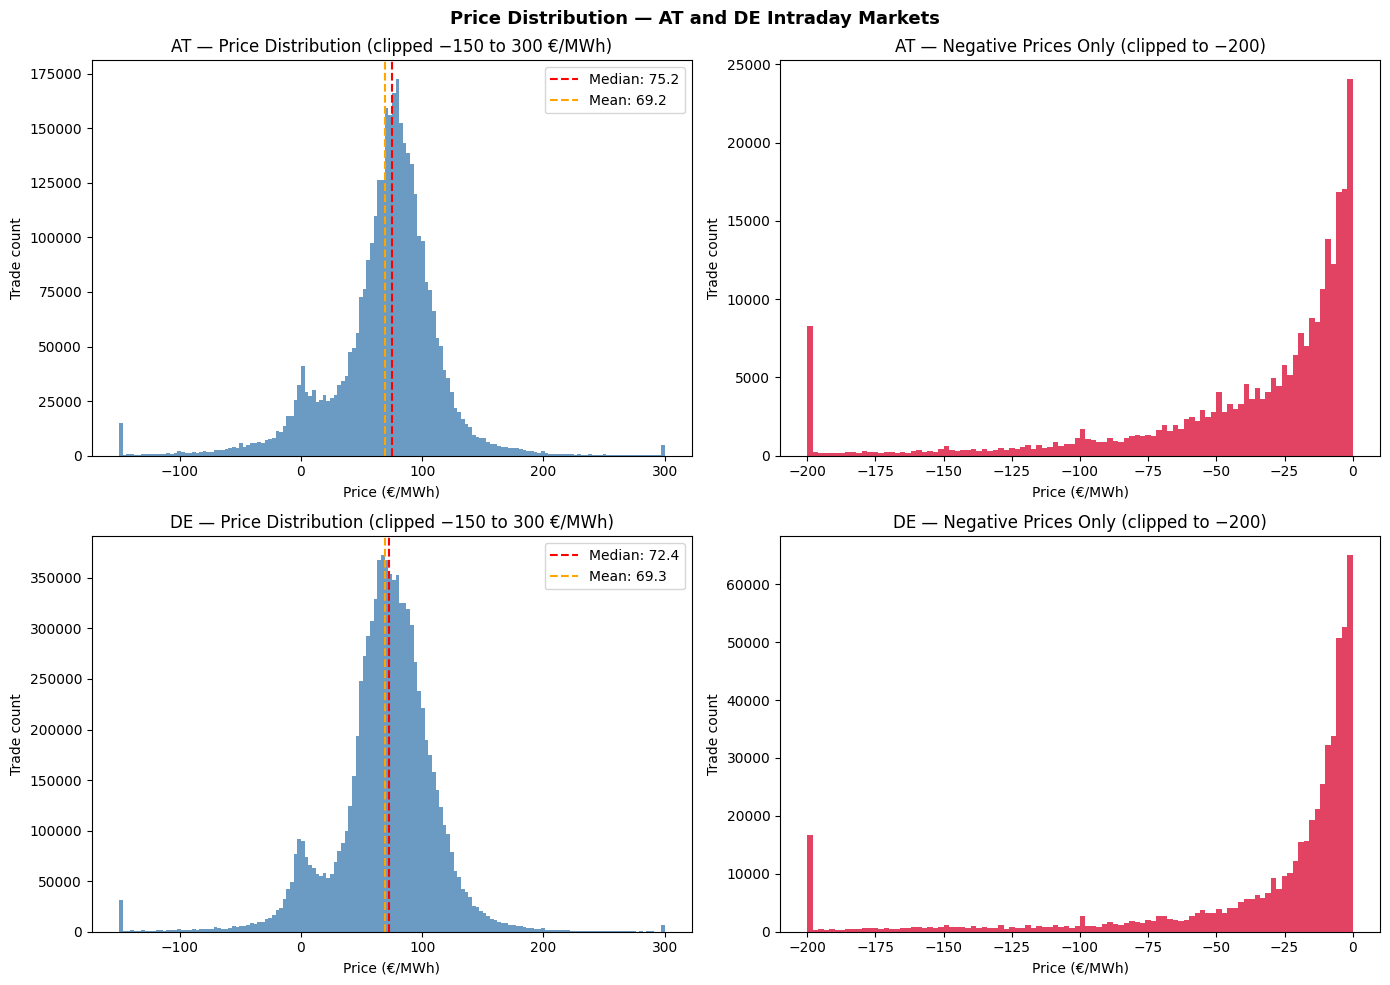

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Price Distribution — AT and DE Intraday Markets", fontsize=13, fontweight="bold")

for row, (name, df) in enumerate([("AT", df_at), ("DE", df_de)]):
    # Full distribution clipped
    ax = axes[row, 0]
    clipped = df["price"].clip(-150, 300)
    ax.hist(clipped, bins=150, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(f"{name} — Price Distribution (clipped −150 to 300 €/MWh)")
    ax.set_xlabel("Price (€/MWh)")
    ax.set_ylabel("Trade count")
    ax.axvline(df["price"].median(), color="red", linestyle="--", label=f"Median: {df['price'].median():.1f}")
    ax.axvline(df["price"].mean(), color="orange", linestyle="--", label=f"Mean: {df['price'].mean():.1f}")
    ax.legend()

    # Negative prices only
    ax = axes[row, 1]
    neg = df[df["price"] < 0]["price"].clip(-200, 0)
    ax.hist(neg, bins=100, color="crimson", edgecolor="none", alpha=0.8)
    ax.set_title(f"{name} — Negative Prices Only (clipped to −200)")
    ax.set_xlabel("Price (€/MWh)")
    ax.set_ylabel("Trade count")

plt.tight_layout()
plt.savefig("../reports/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
print("Saved → ../reports/price_distribution.png")

Saved → ../reports/price_distribution.png


## 5. Volume Over Time

Daily traded volume shows how active the market is across the observation period. Both the number of trades and the total quantity in MW are shown.

Systematic drops in volume on weekends are expected — industrial demand falls and trading activity reduces accordingly. Sudden drops may indicate data gaps or public holidays.

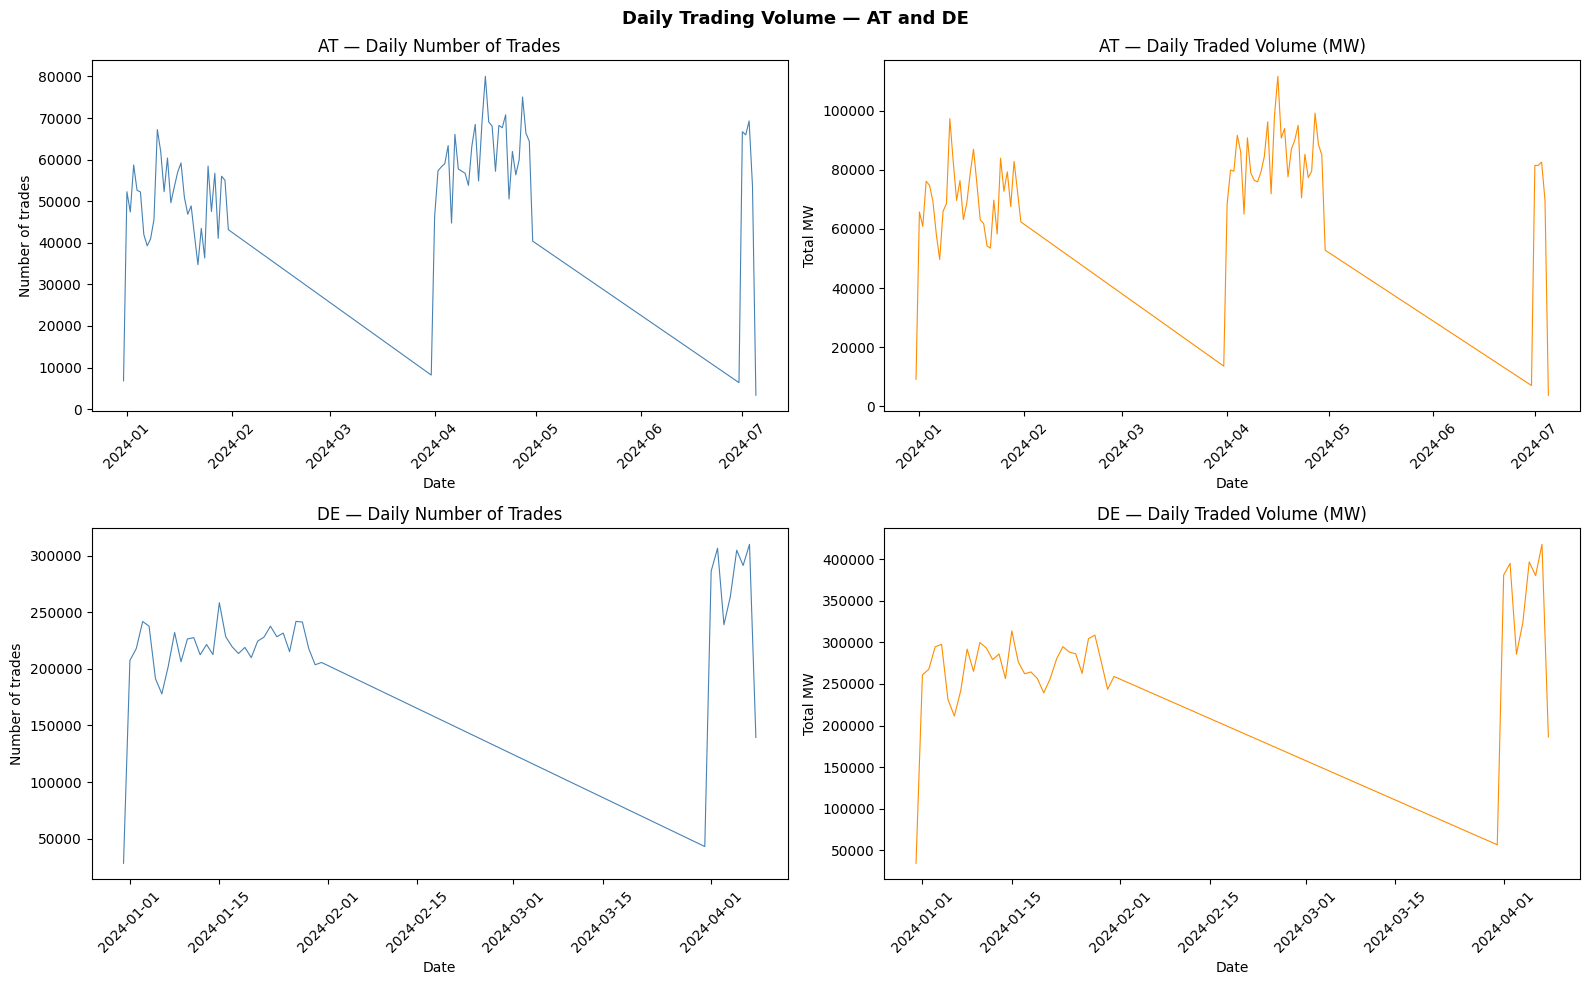

Saved → ../reports/daily_volume.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Daily Trading Volume — AT and DE", fontsize=13, fontweight="bold")

for row, (name, df) in enumerate([("AT", df_at), ("DE", df_de)]):
    daily_trades = df.groupby("date").size().reset_index(name="n_trades")
    daily_mw     = df.groupby("date")["quantity"].sum().reset_index(name="total_mw")

    ax = axes[row, 0]
    ax.plot(pd.to_datetime(daily_trades["date"]), daily_trades["n_trades"],
            linewidth=0.8, color="steelblue")
    ax.set_title(f"{name} — Daily Number of Trades")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of trades")
    ax.tick_params(axis="x", rotation=45)

    ax = axes[row, 1]
    ax.plot(pd.to_datetime(daily_mw["date"]), daily_mw["total_mw"],
            linewidth=0.8, color="darkorange")
    ax.set_title(f"{name} — Daily Traded Volume (MW)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total MW")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../reports/daily_volume.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/daily_volume.png")

## 6. Hourly Price Patterns

The volume-weighted average price (VWAP) by hour reveals the intraday price curve. VWAP is used instead of a simple mean because it weights prices by how much was traded at each price — a more accurate representation of the true market level.

The typical intraday pattern in Central European power markets shows:
- **Overnight hours (0–5):** lower prices, low demand
- **Morning ramp (6–9):** prices rise as industrial demand starts
- **Midday (10–14):** solar generation peaks, can push prices down in summer
- **Evening peak (17–20):** demand peaks as industry and households overlap
- **Night (21–23):** prices fall again

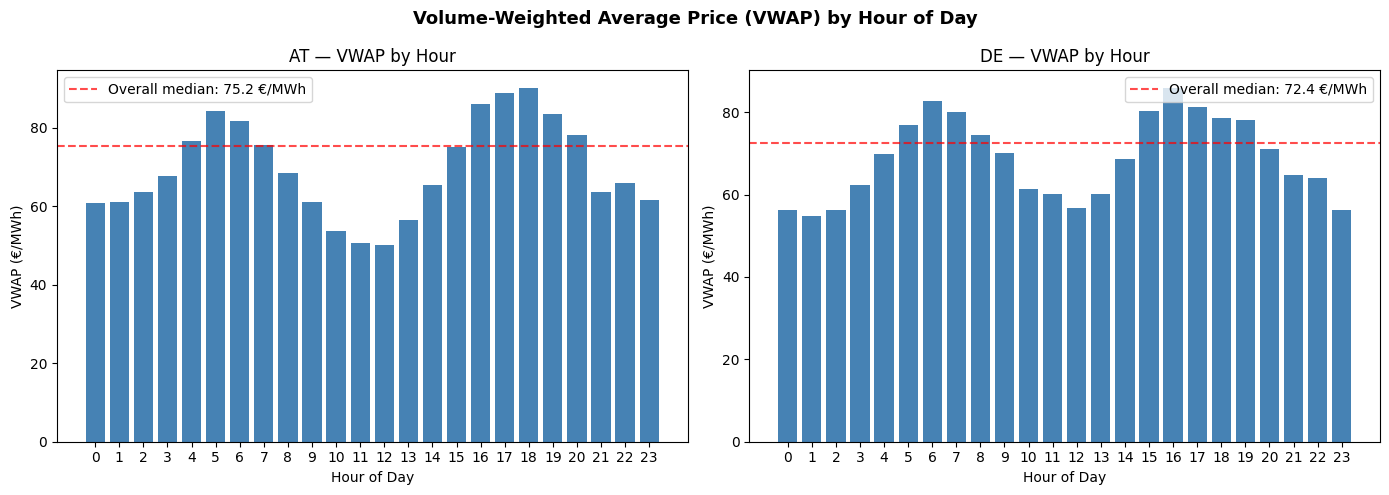

Saved → ../reports/vwap_by_hour.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VWAP by Trade Execution Hour (when the deal was struck)", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("AT", df_at), ("DE", df_de)]):
    vwap = (
        df.groupby("hour")
        .apply(lambda g: np.average(g["price"], weights=g["quantity"]), include_groups=False)
        .rename("vwap")
        .reset_index()
    )
    ax.bar(vwap["hour"], vwap["vwap"], color="steelblue", edgecolor="none")
    ax.axhline(df["price"].median(), color="red", linestyle="--", alpha=0.7,
               label=f"Overall median: {df['price'].median():.1f} €/MWh")
    ax.set_title(f"{name} — VWAP by Hour")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("VWAP (€/MWh)")
    ax.set_xticks(range(0, 24))
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/vwap_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/vwap_by_hour.png")

## 7. Monthly Price Patterns

Monthly VWAP shows seasonal trends across the observation period. Winter months typically show higher prices due to higher heating demand and less solar generation. Spring and summer bring more solar which can suppress midday prices and increase negative price frequency.

IndexError: list index out of range

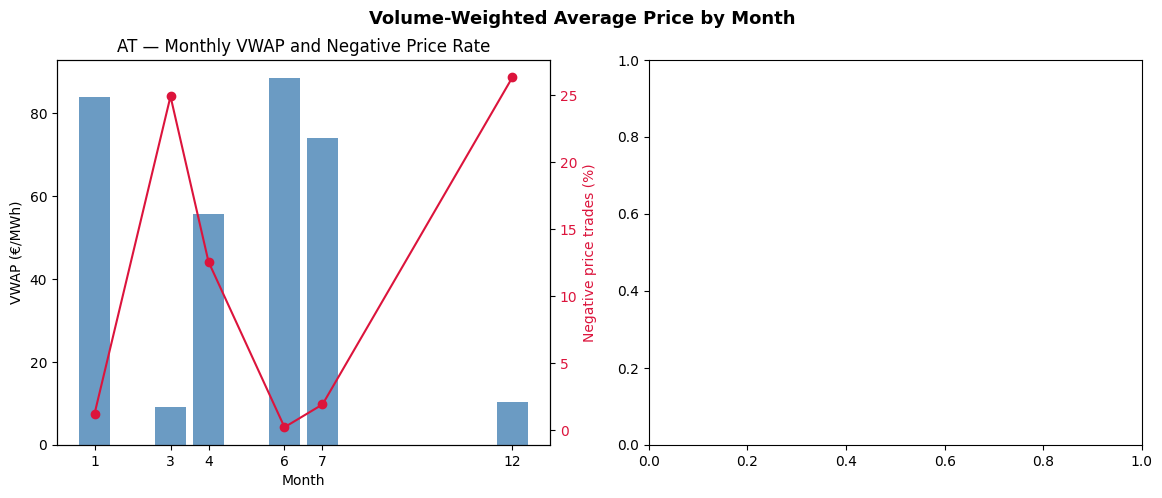

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Volume-Weighted Average Price by Month", fontsize=13, fontweight="bold")

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]

for ax, (name, df) in zip(axes, [("AT", df_at), ("DE", df_de)]):
    vwap_month = (
        df.groupby("month")
        .apply(lambda g: np.average(g["price"], weights=g["quantity"]), include_groups=False)
        .rename("vwap")
        .reset_index()
    )
    neg_pct = df[df["price"] < 0].groupby("month").size() / df.groupby("month").size() * 100

    ax2 = ax.twinx()
    ax2.plot(vwap_month["month"], neg_pct.reindex(vwap_month["month"]).values,
             color="crimson", marker="o", linewidth=1.5, label="Negative price %")
    ax2.set_ylabel("Negative price trades (%)", color="crimson")
    ax2.tick_params(axis="y", labelcolor="crimson")

    ax.bar(vwap_month["month"], vwap_month["vwap"], color="steelblue",
           edgecolor="none", alpha=0.8, label="VWAP")
    ax.set_title(f"{name} — Monthly VWAP and Negative Price Rate")
    ax.set_xlabel("Month")
    ax.set_ylabel("VWAP (€/MWh)")
    months_present = sorted(df["month"].unique())
    ax.set_xticks(months_present)
    ax.set_xticklabels([month_labels[m-1] for m in months_present])
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig("../reports/monthly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/monthly_patterns.png")

## 8. Delivery Area Breakdown

Each trade has a buy and a sell delivery area. The area codes are EIC identifiers assigned to each Transmission System Operator (TSO) zone. Understanding which zones are most active reveals the cross-border flow patterns in the data.

A trade where `buy_delivery_area != sell_delivery_area` is a cross-border trade — electricity physically flows across a national or TSO border.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Delivery Area Activity", fontsize=13, fontweight="bold")

for row, (name, df) in enumerate([("AT", df_at), ("DE", df_de)]):
    top_buy = df["buy_delivery_area"].value_counts().head(8)
    top_sell = df["sell_delivery_area"].value_counts().head(8)

    ax = axes[row, 0]
    ax.barh(top_buy.index[::-1], top_buy.values[::-1], color="steelblue")
    ax.set_title(f"{name} — Top Buy Delivery Areas")
    ax.set_xlabel("Number of trades")

    ax = axes[row, 1]
    ax.barh(top_sell.index[::-1], top_sell.values[::-1], color="darkorange")
    ax.set_title(f"{name} — Top Sell Delivery Areas")
    ax.set_xlabel("Number of trades")

plt.tight_layout()
plt.savefig("../reports/delivery_areas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../reports/delivery_areas.png")

## 9. Cross-Border Flow Summary

Cross-border trades are trades where the buyer and seller are in different TSO zones. These flows are driven by price differences between zones — electricity flows from cheaper areas to more expensive ones.

The high cross-border rate in both markets (AT: 65%, DE: 78%) reflects the deeply integrated Central European power market where price signals constantly drive electricity across borders.

In [ ]:
for name, df in [("AT", df_at), ("DE", df_de)]:
    print(f"=== {name} ===")
    print(f"  Cross-border trades : {df['cross_border'].mean():.2%}")
    print(f"  Domestic trades     : {(~df['cross_border']).mean():.2%}")
    print()
    # Top cross-border pairs
    cross = df[df["cross_border"]].copy()
    cross["pair"] = cross["buy_delivery_area"] + " → " + cross["sell_delivery_area"]
    print("  Top 5 cross-border pairs:")
    print(cross["pair"].value_counts().head(5).to_string())
    print()

## 10. Summary of Key Findings

This notebook has characterised the basic statistical properties of intraday trade prices in both the Austrian and German markets. Key findings:

**Price level and distribution**
- Both markets trade around 69 €/MWh on average, tightly coupled by cross-border flows
- Both distributions are left-skewed — extreme negative prices pull the mean below the median
- 90% of all trades fall between approximately −9 and +127 €/MWh

**Negative prices**
- AT: 7.0% of trades at negative prices — higher rate than DE
- DE: 5.9% of trades at negative prices
- Negative prices peak during morning hours when solar generation ramps up
- AT's higher negative price rate likely reflects run-of-river hydro oversupply

**Market structure**
- Both markets are dominated by cross-border trades (AT: 65%, DE: 78%)
- All trades involve at least one domestic area — confirming data filters correctly
- DE is significantly more liquid: 2.5× more trades despite a shorter observation period

**Next steps (EDA03)**
- Download weather data (solar irradiance, wind speed) for the AT and DE regions
- Correlate weather variables with price levels and negative price frequency
- Investigate forecast error impact on intraday price movements